In [ ]:
import datetime
import pandas as pd
import plotly.graph_objects as go
from data_manager import DataMaster 

try:
    dm = DataMaster(raw_data)
    print("✅ DataMaster réinitialisé avec succès.")
except NameError:
    # Sinon, on recharge tout proprement
    print("🔄 Chargement initial des données...")
    from data_loader import load_period
    raw_data = load_period(start_year=2026, start_month=1)
    dm = DataMaster(raw_data)
    print("✅ Données rechargées et DataMaster prêt.")

start_date = datetime.date(2026, 1, 5)
days_to_show = []
current_date = start_date
while len(days_to_show) < 5:
    if current_date.weekday() < 5:
        days_to_show.append(current_date)
    current_date += datetime.timedelta(days=1)

for target_day in days_to_show:
    try:
        history, session, symbol = dm.get_market_context(target_day)
        
        if session is None or session.empty:
            print(f"⚠️ Aucune donnée pour le {target_day}")
            continue

        levels = dm.calculate_ict_levels(history, session)

        # Transformation H1
        session_h1 = session.resample('1h').agg({
            'open': 'first', 'high': 'max', 'low': 'min', 'close': 'last'
        }).dropna()

        fig = go.Figure(data=[go.Candlestick(
            x=session_h1.index,
            open=session_h1['open'], high=session_h1['high'],
            low=session_h1['low'], close=session_h1['close'],
            name=f"{symbol} H1"
        )])
        
        # Lignes ICT
        fig.add_hline(y=levels['mid'], line_color="cyan", line_width=2, 
                      annotation_text=f"Midnight Open: {levels['mid']}")
        
        if levels['pdh']:
            fig.add_hline(y=levels['pdh'], line_color="red", line_dash="dash", 
                          annotation_text=f"PDH: {levels['pdh']}")
        
        if levels['pdl']:
            fig.add_hline(y=levels['pdl'], line_color="green", line_dash="dash", 
                          annotation_text=f"PDL: {levels['pdl']}")

        fig.update_layout(
            title=f"NQ H1 - {target_day}",
            template="plotly_dark",
            xaxis_rangeslider_visible=False,
            hovermode="x unified",
            height=600
        )
        
        fig.show()
        
    except Exception as e:
        print(f"❌ Erreur le {target_day}: {e}")

In [1]:
import datetime
import pandas as pd
import plotly.graph_objects as go
from data_manager import DataMaster 
from data_loader import load_period

raw_data = load_period(
    start_year=2025, start_month=1, 
    end_year=2025, end_month=3
)
dm = DataMaster(raw_data)

start_date = datetime.date(2025, 1, 15)
days_to_show = [start_date + datetime.timedelta(days=i) for i in range(60)]

Target: 1/2025 to 3/2025
📥 Loading: MNQ_2025_01.pkl
📥 Loading: MNQ_2025_02.pkl
📥 Loading: MNQ_2025_03.pkl
✅ Terminé : 153747 lignes chargées.


REPORT ID: MNQH5 | DATE: 2025-01-15 
 [MARKET CONTEXT]
 ├─ Midnight Open : 20944.5
 ├─ PO3 Status    : ⚠️ Expansion
 ├─ Range Ratio   : 4.2 (Target < 0.75)
 └─ Vol. Ratio    : 1.0

 [LIQUIDITY MAP H1]
 ├─ BSL (Highs)    : 21329.0, 21143.75, 21015.75, 20971.5
 ├─ SSL (Lows)     : 20773.25, 20908.75, 20926.0, 20957.5, 20977.25
 └─ Daily Levels   : PDH: 21143.75 | PDL: 20773.25

 [EXECUTION & RESULTS]
    >> No valid 'Grade A' setup detected. Market did not meet sweep + rejection criteria.
Aucun trade exécuté aujourd'hui.
REPORT ID: MNQH5 | DATE: 2025-01-16 
 [MARKET CONTEXT]
 ├─ Midnight Open : 21389.75
 ├─ PO3 Status    : ⚠️ Expansion
 ├─ Range Ratio   : 2.14 (Target < 0.75)
 └─ Vol. Ratio    : 1.0

 [LIQUIDITY MAP H1]
 ├─ BSL (Highs)    : 21566.75, 21548.5, 21519.0, 21452.75
 ├─ SSL (Lows)     : 20908.75, 21404.0, 21445.0, 21454.25, 21484.0, 21504.75
 └─ Daily Levels   : PDH: 21452.75 | PDL: 20908.75

 [EXECUTION & RESULTS]
    >> No valid 'Grade A' setup detected. Market did not meet 

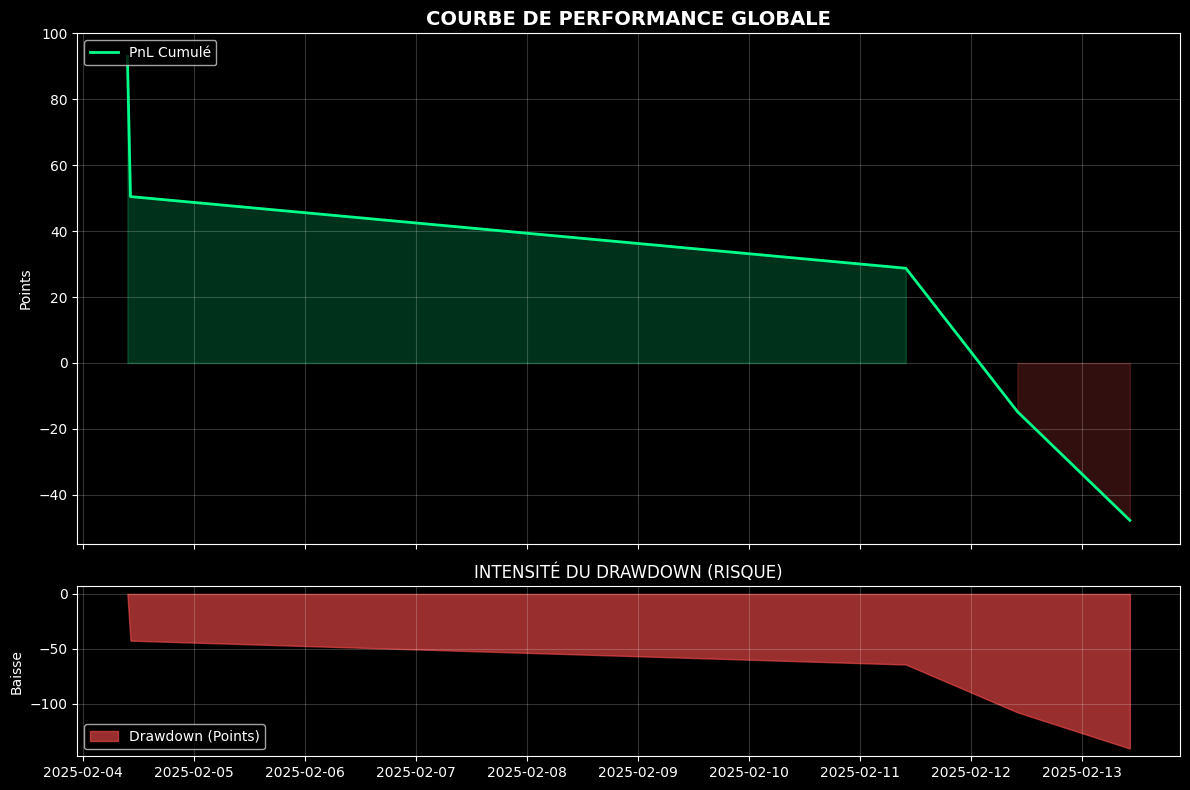

In [2]:
# --- Rendu Notebook Style "Engineering Report" ---

for target_day in days_to_show:
    history, session, symbol = dm.get_market_context(target_day)
    if session is None or session.empty: continue

    levels = dm.calculate_ict_levels(history, session)
    signals = dm.detect_signals(session, levels)
    dm.collect_daily_results(signals)
    po3 = dm.analyze_po3(history, session)


    print(f"REPORT ID: {symbol} | DATE: {target_day} ")

    # --- SECTION 1: CONTEXTE & PO3 ---
    status_icon = "💎" if po3['is_po3'] and "PREMIUM" in po3['status'] else "✅" if po3['is_po3'] else "⚠️"
    print(f" [MARKET CONTEXT]")
    print(f" ├─ Midnight Open : {levels.get('mid', 'N/A')}")
    print(f" ├─ PO3 Status    : {status_icon} {po3['status']}")
    print(f" ├─ Range Ratio   : {po3['range_ratio']} (Target < 0.75)")
    print(f" └─ Vol. Ratio    : {po3['vol_ratio']}\n")
    # --- SECTION 2: LIQUIDITY MAP H1 ---
    print(f" [LIQUIDITY MAP H1]")
    print(f" ├─ BSL (Highs)    : {', '.join(map(str, levels.get('major_highs', [])))}")
    print(f" ├─ SSL (Lows)     : {', '.join(map(str, levels.get('major_lows', [])))}")
    print(f" └─ Daily Levels   : PDH: {levels.get('pdh')} | PDL: {levels.get('pdl')}\n")

    # --- SECTION 3: EXECUTION & RESULTS ---
    print(f" [EXECUTION & RESULTS]")
    if not signals:
        print("    >> No valid 'Grade A' setup detected. Market did not meet sweep + rejection criteria.")
    else:
        for s in signals:
            res_icon = "💰" if "WIN" in s['res'] else "❌" if "LOSS" in s['res'] else "🕒"
            # Affichage de l'heure d'entrée et de sortie (IN/OUT)
            print(f"    {s['time'].strftime('%H:%M')} | {s['type']} | {res_icon} {s['res']}")
            print(f"    ├─ ENTRY (OTE) : {s['entry']}")
            print(f"    ├─ TARGET (TP) : {s['tp']} (RR: 2.0)")
            print(f"    ├─ PROTECTION  : {s['sl']} (Risk: {round(abs(s['entry']-s['sl']), 2)} pts)")
            print(f"    └─ P&L POINTS  : {s['pnl']} pts")
            print("")

    # --- SECTION 4: RISK & PERFORMANCE TRACKING ---
    # Ici on affiche le résumé de la session
    print(dm.generate_session_report())

# =================================================================
# 🏁 FINAL ANALYSIS (Appelé une seule fois à la fin de la boucle)
# =================================================================
print(f"FINAL PERFORMANCE OVERVIEW (FULL PERIOD)")
print(f" TOTAL ACCUMULATED P&L: {round(dm.cumulative_pnl, 2)} POINTS")
print(f"{'═'*85}")

# Lancement du Stress-Test complet (la fonction qu'on a codée ensemble)
dm.get_full_risk_analysis() 
